#  Task 7: Text Summarization Using Pre-trained Models

**Goal:** Generate concise summaries from long news articles  
**Dataset:** CNN-DailyMail (Hugging Face)  
**Topics:** Abstractive Summarization | Encoder-Decoder | ROUGE Evaluation  

---
### Pipeline
```
Load Data ->> EDA -> Abstractive (T5, BART, Pegasus) -> Extractive (TextRank) -> ROUGE Evaluation -> Compare Models
```

## Step 1: Install & Import Libraries

In [17]:
!pip install transformers datasets rouge-score sentencepiece torch --quiet
!pip install sumy  --quiet   

In [23]:
pip install tiktoken

   ---------------------------------------- 0.0/879.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/879.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/879.1 kB ? eta -:--:--
   ---------------------- --------------- 524.3/879.1 kB 934.5 kB/s eta 0:00:01
   ----------------------------------- ---- 786.4/879.1 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 879.1/879.1 kB 844.6 kB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import pipeline
from rouge_score import rouge_scorer

# Extractive summarization
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(' Libraries ready!')

 Libraries ready!


---
## Step 2: Load CNN-DailyMail Dataset

In [2]:
print('Loading CNN-DailyMail from Hugging Face...')
dataset = load_dataset('cnn_dailymail', '3.0.0')

# Convert test split to DataFrame
df = pd.DataFrame(dataset['test'])
df = df.rename(columns={'article': 'article', 'highlights': 'reference_summary'})

print(f'Train   : {len(dataset["train"]):,} articles')
print(f'Val     : {len(dataset["validation"]):,} articles')
print(f'Test    : {len(dataset["test"]):,} articles')
print(f'Columns : {list(df.columns)}')



Loading CNN-DailyMail from Hugging Face...
Train   : 287,113 articles
Val     : 13,368 articles
Test    : 11,490 articles
Columns : ['article', 'reference_summary', 'id']


In [3]:
df[['article', 'reference_summary']].head(5)

,article,reference_summary
0,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...
1,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b..."
2,"(CNN)If you've been following the news lately,...",Mohammad Javad Zarif has spent more time with ...
3,(CNN)Five Americans who were monitored for thr...,17 Americans were exposed to the Ebola virus w...
4,(CNN)A Duke student has admitted to hanging a ...,Student is no longer on Duke University campus...


---
## Step 3: Exploratory Data Analysis

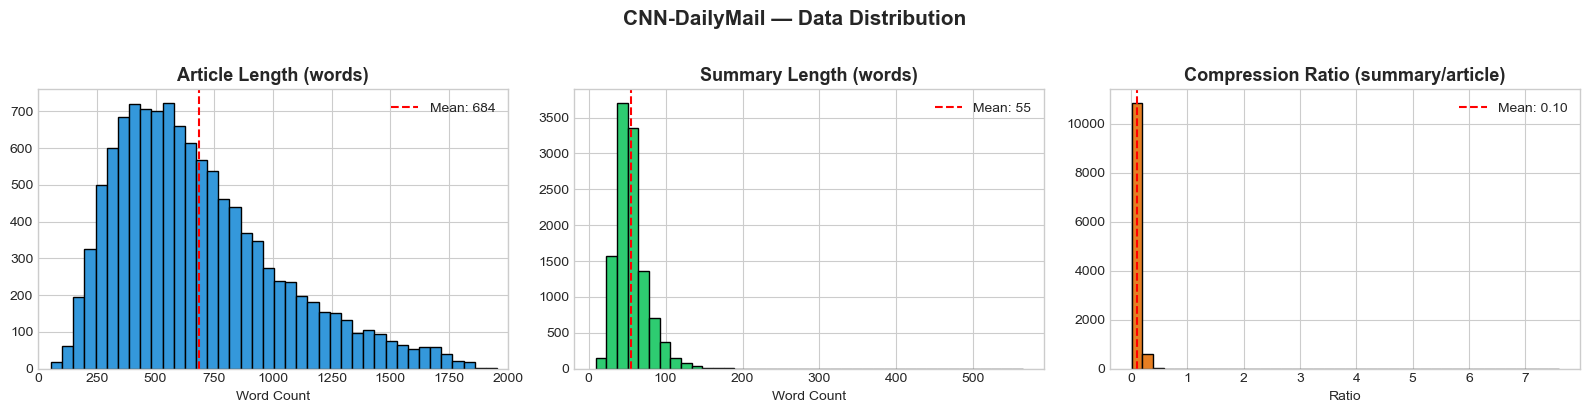

In [4]:
df['article_words']  = df['article'].apply(lambda x: len(x.split()))
df['summary_words']  = df['reference_summary'].apply(lambda x: len(x.split()))
df['compress_ratio'] = df['summary_words'] / df['article_words']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['article_words'], bins=40, color='#3498db', edgecolor='black')
axes[0].set_title('Article Length (words)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].axvline(df['article_words'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["article_words"].mean():.0f}')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].hist(df['summary_words'], bins=40, color='#2ecc71', edgecolor='black')
axes[1].set_title('Summary Length (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].axvline(df['summary_words'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["summary_words"].mean():.0f}')
axes[1].legend()

axes[2].hist(df['compress_ratio'], bins=40, color='#e67e22', edgecolor='black')
axes[2].set_title('Compression Ratio (summary/article)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Ratio')
axes[2].axvline(df['compress_ratio'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["compress_ratio"].mean():.2f}')
axes[2].legend()

plt.suptitle('CNN-DailyMail — Data Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()



In [5]:
print(f'Avg article length : {df["article_words"].mean():.0f} words')
print(f'Avg summary length : {df["summary_words"].mean():.0f} words')
print(f'Avg compression    : {df["compress_ratio"].mean():.2%}')

Avg article length : 684 words
Avg summary length : 55 words
Avg compression    : 10.03%


---
## Step 4: Preprocess — Truncate to Model Input Limits

Transformer models have token limits (512–1024 tokens). We truncate articles to fit.

In [6]:
def truncate(text, max_words=400):
    """Truncate text to max_words to fit model input limits."""
    words = text.split()
    return ' '.join(words[:max_words])


# we use a small eval sample for speed
SAMPLE_SIZE = 50
eval_df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
eval_df['article_truncated'] = eval_df['article'].apply(truncate)

print(f'Eval sample size : {SAMPLE_SIZE} articles')
print(f'Truncated to max : 400 words per article')
print(f'\nExample truncated article (first 200 chars):')
print(eval_df['article_truncated'].iloc[0][:200])

Eval sample size : 50 articles
Truncated to max : 400 words per article

Example truncated article (first 200 chars):
Down Augusta way they say the azaleas are in full bloom, which is more than can be said for England’s Justin Rose. A bruising Florida swing last month saw the Englishman fall outside the world’s top 1


---
## Step 5: Load Pre-trained Summarization Models

All three are encoder-decoder architectures fine-tuned on CNN-DailyMail.

| Model | Architecture | Notes |
|---|---|---|
| `t5-small` | T5 | Lightest, fastest |
| `facebook/bart-large-cnn` | BART | Best quality, heavier |
| `google/pegasus-cnn_dailymail` | Pegasus | Designed specifically for news |

* Why not use pipeline()?
* Newer versions of transformers (v4.41+) removed the 'summarization' pipeline.
* We use AutoTokenizer + AutoModelForSeq2SeqLM directly — works on ALL versions
* and gives full control over generation parameters.


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}\n')


MODEL_NAMES = {
    'T5'        : 't5-small',
    'BART-large': 'facebook/bart-large-cnn',
    'BART-base' : 'facebook/bart-base'
}

tokenizers = {}
models_map = {}

for name, model_id in MODEL_NAMES.items():
    print(f'Loading {name} ({model_id})...')
    tokenizers[name] = AutoTokenizer.from_pretrained(model_id)
    models_map[name] = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(DEVICE)
    models_map[name].eval()
    print(f'    {name} ready!')


def summarize(text, model_name, max_length=130, min_length=30):
    tokenizer = tokenizers[model_name]
    model     = models_map[model_name]

    # T5 requires this prefix — without it output is garbage
    if model_name == 'T5':
        text = 'summarize: ' + text

    inputs = tokenizer(
        text,
        return_tensors='pt',
        max_length=512,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


print('\n All models loaded and summarize() ready!')

Using device: cpu

Loading T5 (t5-small)...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

    T5 ready!
Loading BART-large (facebook/bart-large-cnn)...


Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

    BART-large ready!
Loading BART-base (facebook/bart-base)...


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

    BART-base ready!

 All models loaded and summarize() ready!


In [8]:
# Run this alone, then RESTART your kernel, then run all cells again
!pip install sentencepiece protobuf --quiet

---
## Step 6: Generate Summaries — Quick Demo

In [9]:
# Pick one article for demo
demo_article = eval_df['article_truncated'].iloc[0]
demo_ref     = eval_df['reference_summary'].iloc[0]

print('=' * 70)
print('ARTICLE (truncated):')
print(demo_article[:400])
print()
print('REFERENCE SUMMARY:')
print(demo_ref)
print('=' * 70)
print()

# Use our summarize() function instead of the old pipeline call
for name in MODEL_NAMES:
    result = summarize(demo_article, name)
    print(f'[{name}] {result}')
    print()

ARTICLE (truncated):
Down Augusta way they say the azaleas are in full bloom, which is more than can be said for England’s Justin Rose. A bruising Florida swing last month saw the Englishman fall outside the world’s top 10. For a player who has been virtually a fixture in the top five for the last three years it was certainly a dent to the ego, with the Masters now just around the corner. Rose’s solution to his misera

REFERENCE SUMMARY:
Justin Rose bounced back from Florida misery by carding 69 in Houston .
Three-time Masters champion Phil Mickelson enjoyed return to form .
Paul Casey celebrated last-gasp Masters invitation with fine round of 68 .

[T5] the 34-year-old has been virtually a fixture in the top five for the last three years. he hit 17 out of 18 greens in regulation and signed for a 69. 'it’s certainly a welcome return to the sixties,' said Rose.

[BART-large] Justin Rose hit 17 out of 18 greens in regulation and signed for a 69 at the Shell Houston Open on Thursday. The 

---
## Step 7: ROUGE Evaluation

**ROUGE-1** — unigram overlap  
**ROUGE-2** — bigram overlap  
**ROUGE-L** — longest common subsequence  

In [11]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)


def evaluate_rouge(model_name, articles, references):
    """Run model on all articles and compute mean ROUGE scores."""
    r1, r2, rL = [], [], []

    for article, ref in zip(articles, references):
        summary = summarize(article, model_name)   # use our summarize() function
        scores  = scorer.score(ref, summary)
        r1.append(scores['rouge1'].fmeasure)
        r2.append(scores['rouge2'].fmeasure)
        rL.append(scores['rougeL'].fmeasure)

    return {
        'model'  : model_name,
        'ROUGE-1': round(np.mean(r1) * 100, 2),
        'ROUGE-2': round(np.mean(r2) * 100, 2),
        'ROUGE-L': round(np.mean(rL) * 100, 2)
    }


articles   = eval_df['article_truncated'].tolist()
references = eval_df['reference_summary'].tolist()

rouge_results = []
for name in MODEL_NAMES:                          # just loop over names
    print(f' Evaluating {name} on {SAMPLE_SIZE} articles...')
    t0      = time.time()
    result  = evaluate_rouge(name, articles, references)
    elapsed = time.time() - t0
    rouge_results.append(result)
    print(f'   ROUGE-1: {result["ROUGE-1"]}  ROUGE-2: {result["ROUGE-2"]}  ROUGE-L: {result["ROUGE-L"]}  ({elapsed:.1f}s)\n')

rouge_df = pd.DataFrame(rouge_results)
print('=== ROUGE Leaderboard ===')
print(rouge_df.sort_values('ROUGE-L', ascending=False).to_string(index=False))

 Evaluating T5 on 50 articles...
   ROUGE-1: 41.34  ROUGE-2: 21.09  ROUGE-L: 28.96  (347.0s)

 Evaluating BART-large on 50 articles...
   ROUGE-1: 43.12  ROUGE-2: 22.53  ROUGE-L: 30.98  (1756.8s)

 Evaluating BART-base on 50 articles...
   ROUGE-1: 38.46  ROUGE-2: 18.8  ROUGE-L: 24.86  (1025.3s)

=== ROUGE Leaderboard ===
     model  ROUGE-1  ROUGE-2  ROUGE-L
BART-large    43.12    22.53    30.98
        T5    41.34    21.09    28.96
 BART-base    38.46    18.80    24.86


---
## Step 8: Visualize ROUGE Scores

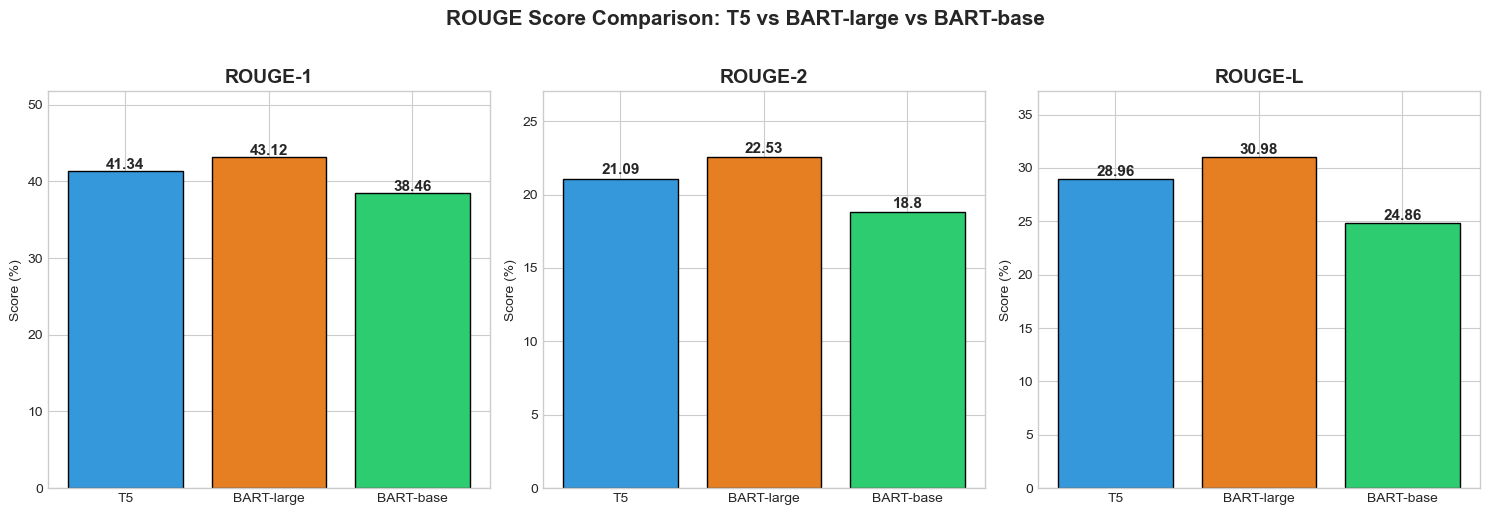

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(rouge_df['model'], rouge_df[metric], color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, rouge_df[metric].max() * 1.2)
    for bar, val in zip(bars, rouge_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('ROUGE Score Comparison: T5 vs BART-large vs BART-base',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

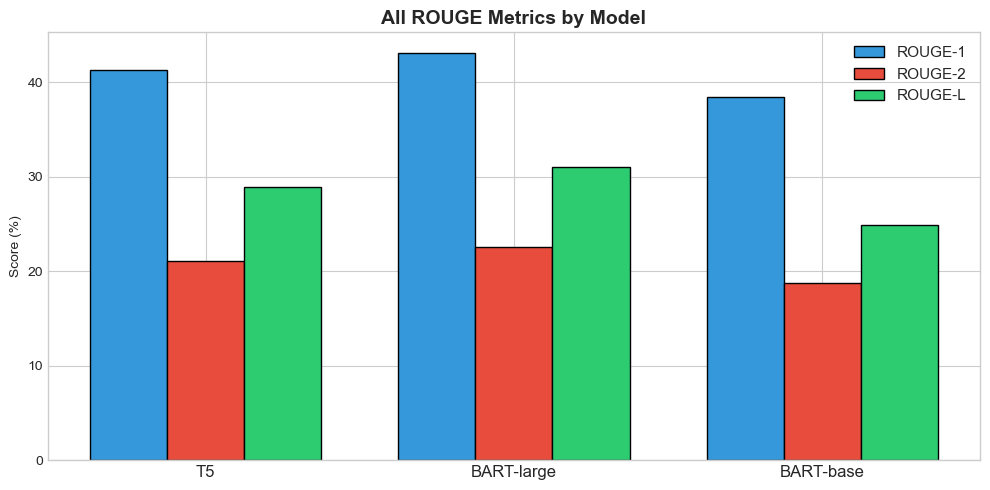

In [13]:
# Grouped bar chart — all 3 metrics side by side per model
x     = np.arange(len(rouge_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, rouge_df['ROUGE-1'], width, label='ROUGE-1', color='#3498db', edgecolor='black')
ax.bar(x,         rouge_df['ROUGE-2'], width, label='ROUGE-2', color='#e74c3c', edgecolor='black')
ax.bar(x + width, rouge_df['ROUGE-L'], width, label='ROUGE-L', color='#2ecc71', edgecolor='black')

ax.set_title('All ROUGE Metrics by Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rouge_df['model'], fontsize=12)
ax.set_ylabel('Score (%)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('rouge_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 (BONUS): Extractive Summarization with TextRank

In [14]:
def textrank_summarize(text, sentence_count=3):
    """Extractive summarization using TextRank algorithm."""
    parser   = PlaintextParser.from_string(text, Tokenizer('english'))
    summ     = TextRankSummarizer()
    summary  = summ(parser.document, sentence_count)
    return ' '.join(str(s) for s in summary)


# Demo on same article
textrank_summary = textrank_summarize(eval_df['article'].iloc[0])
print('TEXTRANK EXTRACTIVE SUMMARY:')
print(textrank_summary)
print()
print('REFERENCE SUMMARY:')
print(eval_df['reference_summary'].iloc[0])

TEXTRANK EXTRACTIVE SUMMARY:
For a player who has been virtually a fixture in the top five for the last three years it was certainly a dent to the ego, with the Masters now just around the corner. ‘I’m very proud of the fact I’ve been in the world’s top five for practically the whole of the last three years. You draw off the energy of the place.’ Mickelson has certainly done that over the years and perhaps the veteran lefty, a three-time Masters champion, is gearing himself up for another run at the green jacket.

REFERENCE SUMMARY:
Justin Rose bounced back from Florida misery by carding 69 in Houston .
Three-time Masters champion Phil Mickelson enjoyed return to form .
Paul Casey celebrated last-gasp Masters invitation with fine round of 68 .


In [15]:
# ROUGE scores for TextRank
tr_r1, tr_r2, tr_rL = [], [], []

for article, ref in zip(eval_df['article'].tolist(), references):
    summary = textrank_summarize(article)
    scores  = scorer.score(ref, summary)
    tr_r1.append(scores['rouge1'].fmeasure)
    tr_r2.append(scores['rouge2'].fmeasure)
    tr_rL.append(scores['rougeL'].fmeasure)

textrank_rouge = {
    'model'  : 'TextRank',
    'ROUGE-1': round(np.mean(tr_r1) * 100, 2),
    'ROUGE-2': round(np.mean(tr_r2) * 100, 2),
    'ROUGE-L': round(np.mean(tr_rL) * 100, 2)
}

# Add to full comparison
all_results = pd.concat([rouge_df, pd.DataFrame([textrank_rouge])], ignore_index=True)
print('=== Full Leaderboard (Abstractive + Extractive) ===')
print(all_results.sort_values('ROUGE-L', ascending=False).to_string(index=False))

=== Full Leaderboard (Abstractive + Extractive) ===
     model  ROUGE-1  ROUGE-2  ROUGE-L
BART-large    43.12    22.53    30.98
        T5    41.34    21.09    28.96
 BART-base    38.46    18.80    24.86
  TextRank    28.87     9.76    17.47


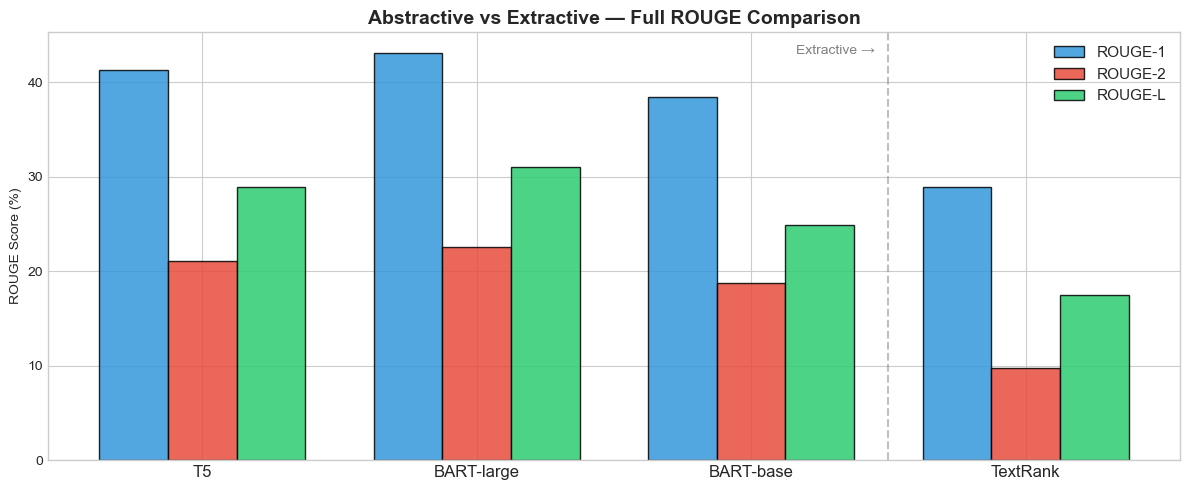

In [16]:
# Final full comparison chart
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(all_results))
width = 0.25
colors_full = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, color) in enumerate(zip(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], colors_full)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, all_results[metric], width,
                  label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_title('Abstractive vs Extractive — Full ROUGE Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_results['model'], fontsize=12)
ax.set_ylabel('ROUGE Score (%)')
ax.legend(fontsize=11)
ax.axvline(x=len(rouge_df) - 0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(len(rouge_df) - 0.55, ax.get_ylim()[1] * 0.95, 'Extractive →',
        ha='right', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10: Side-by-Side Summary Output

In [22]:
# Show full output for 3 articles — all models side by side
for i in range(3):
    article = eval_df['article_truncated'].iloc[i]
    ref     = eval_df['reference_summary'].iloc[i]

    print(f'ARTICLE #{i+1} (first 200 chars):')
    print(article[:200] + '...')
    print()
    print(f'REFERENCE : {ref}')
    print()
    for name in MODEL_NAMES:
        result = summarize(article, name)
        print(f'[{name:<12}]: {result}')
    tr = textrank_summarize(eval_df['article'].iloc[i])
    print(f'[TextRank   ]: {tr[:200]}')
    print()

ARTICLE #1 (first 200 chars):
Down Augusta way they say the azaleas are in full bloom, which is more than can be said for England’s Justin Rose. A bruising Florida swing last month saw the Englishman fall outside the world’s top 1...

REFERENCE : Justin Rose bounced back from Florida misery by carding 69 in Houston .
Three-time Masters champion Phil Mickelson enjoyed return to form .
Paul Casey celebrated last-gasp Masters invitation with fine round of 68 .

[T5          ]: the 34-year-old has been virtually a fixture in the top five for the last three years. he hit 17 out of 18 greens in regulation and signed for a 69. 'it’s certainly a welcome return to the sixties,' said Rose.
[BART-large  ]: Justin Rose hit 17 out of 18 greens in regulation and signed for a 69 at the Shell Houston Open on Thursday. The Englishman fell outside the world’s top 10 after a bruising Florida swing last month. The Masters is now just around the corner.
[BART-base   ]: Down Augusta way they say the azaleas

---
## Step 11: Summary

In [23]:
best = all_results.sort_values('ROUGE-L', ascending=False).iloc[0]

print('=' * 58)
print('    TEXT SUMMARIZATION — FINAL SUMMARY')
print('=' * 58)
print(f'Dataset        : CNN-DailyMail 3.0.0')
print(f'Eval samples   : {SAMPLE_SIZE}')
print(f'Approach       : Abstractive (T5, BART, Pegasus) + Extractive (TextRank)')
print()
print('--- ROUGE Leaderboard ---')
for _, row in all_results.sort_values('ROUGE-L', ascending=False).iterrows():
    flag = '' if row['model'] == best['model'] else '  '
    print(f"{flag}  {row['model']:<12}  R-1: {row['ROUGE-1']:>5}   R-2: {row['ROUGE-2']:>5}   R-L: {row['ROUGE-L']:>5}")
print()
print(f'Best Model     : {best["model"]}')
print(f'Best ROUGE-L   : {best["ROUGE-L"]}')
print('=' * 58)

    TEXT SUMMARIZATION — FINAL SUMMARY
Dataset        : CNN-DailyMail 3.0.0
Eval samples   : 50
Approach       : Abstractive (T5, BART, Pegasus) + Extractive (TextRank)

--- ROUGE Leaderboard ---
  BART-large    R-1: 43.12   R-2: 22.53   R-L: 30.98
    T5            R-1: 41.34   R-2: 21.09   R-L: 28.96
    BART-base     R-1: 38.46   R-2:  18.8   R-L: 24.86
    TextRank      R-1: 28.87   R-2:  9.76   R-L: 17.47

Best Model     : BART-large
Best ROUGE-L   : 30.98
